### Imports and Ray Initialization

In [1]:
import ray
import os
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from agamoo_ray import AGAMOO, Evaluator
from agamoo_ray.players import ClonalSelection, CuckooSearch, PSO, SimulatedAnnealing
from agamoo_ray.objectives.treproblems import RE33

from pymoo.indicators.hv import HV
from pygmo import hypervolume

def normalize(values, fmin, fmax):
    return (values - fmin) / (fmax - fmin)

# Initialize the Ray distributed execution engine
os.environ["RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO"] = "0"
if not ray.is_initialized():
    ray.init()
resources = ray.cluster_resources()
NCPU = int(resources.get("CPU", 0))
print(NCPU)

2026-08-16 17:43:02,807	WARNING services.py:2137 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 67108864 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=10.24gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-08-16 17:43:03,272	INFO worker.py:1998 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


128


### Experiment Definition

In [2]:
max_eval = 10000
max_front = 100
change_iter = 1
exchange_iter = 3
next_iter = -1
log_freq = 5
npop = 25

In [3]:
nobj = 3
objs = []
for i in range(3):
    obj = eval(f'RE33({i}, obj={i+1})')
    objs.append(obj)
nvar = obj.n_var
bounds = obj.bounds

#### ClonalSelection

In [4]:
np.random.seed(41)
player_parm = { "nclone": 12, "mutate_args": [0.15, 0.85, 0.005], 'sup': 0.0, 'strategy': 'base'}
agamoo = AGAMOO(max_eval, change_iter, exchange_iter, next_iter, max_front, assign_gens='random', log_freq=log_freq, sup_mode='objectives')
storage = agamoo.create_storage(nvar, nobj, num_cpus=nobj)
evaluators = [Evaluator.options(num_cpus=1).remote(objs) for _ in range(len(objs)-1)]
players = [ClonalSelection.options(num_cpus=1).remote(i, npop, player_parm, obj, storage, gens='pattern', exchange='front_sup_80') for i, obj in zip(range(nobj), objs)]
agamoo.init_players(players, evaluators)
agamoo.start_optimize(tqdm_disable=False)
res1=agamoo.get_results()
hist1 = agamoo.get_history()

  0%|          | 0/10000 [00:00<?, ?eval/s]

#### CuckooSearch

In [5]:
np.random.seed(41)
player_parm = { "pa": 0.25, "beta": 1.5, 'alpha': 0.01, 'strategy': 'algorithm'}
agamoo = AGAMOO(max_eval, change_iter, exchange_iter, next_iter, max_front, assign_gens='random', log_freq=log_freq, sup_mode='objectives')
storage = agamoo.create_storage(nvar, nobj, num_cpus=nobj)
evaluators = [Evaluator.options(num_cpus=1).remote(objs) for _ in range(len(objs)-1)]
players = [CuckooSearch.options(num_cpus=1).remote(i, npop, player_parm, obj, storage, gens='pattern', exchange='front_sup_80') for i, obj in zip(range(nobj), objs)]
agamoo.init_players(players, evaluators)
agamoo.start_optimize(tqdm_disable=False)
res2=agamoo.get_results()
hist2 = agamoo.get_history()

  0%|          | 0/10000 [00:00<?, ?eval/s]

#### PSO

In [6]:
np.random.seed(41)
player_parm = {"w": 0.729, "c1": 1.49445, 'c2': 1.49445}
agamoo = AGAMOO(max_eval, change_iter, exchange_iter, next_iter, max_front, assign_gens='random', log_freq=log_freq, sup_mode='objectives')
storage = agamoo.create_storage(nvar, nobj, num_cpus=nobj)
evaluators = [Evaluator.options(num_cpus=1).remote(objs) for _ in range(len(objs)-1)]
players = [PSO.options(num_cpus=1).remote(i, npop, player_parm, obj, storage, gens='pattern', exchange='front_sup_80') for i, obj in zip(range(nobj), objs)]
agamoo.init_players(players, evaluators)
agamoo.start_optimize(tqdm_disable=False)
res3=agamoo.get_results()
hist3 = agamoo.get_history()

  0%|          | 0/10000 [00:00<?, ?eval/s]

#### SimulatedAnnealing

In [7]:
npop = 5 #dużo mniejsza liczba osobników
np.random.seed(41)
player_parm = {"T0": 100, "T_min": 1e-5, 'step_size': 0.05, 'max_eval': max_eval}
agamoo = AGAMOO(max_eval, change_iter, exchange_iter, next_iter, max_front, assign_gens='random', log_freq=log_freq, sup_mode='objectives')
storage = agamoo.create_storage(nvar, nobj, num_cpus=nobj)
evaluators = [Evaluator.options(num_cpus=1).remote(objs) for _ in range(len(objs)-1)]
players = [SimulatedAnnealing.options(num_cpus=1).remote(i, npop, player_parm, obj, storage, gens='pattern', exchange='front_sup_80') for i, obj in zip(range(nobj), objs)]
agamoo.init_players(players, evaluators)
agamoo.start_optimize(tqdm_disable=False)
res4=agamoo.get_results()
hist4 = agamoo.get_history()

  0%|          | 0/10000 [00:00<?, ?eval/s]

### Pareto front comparison

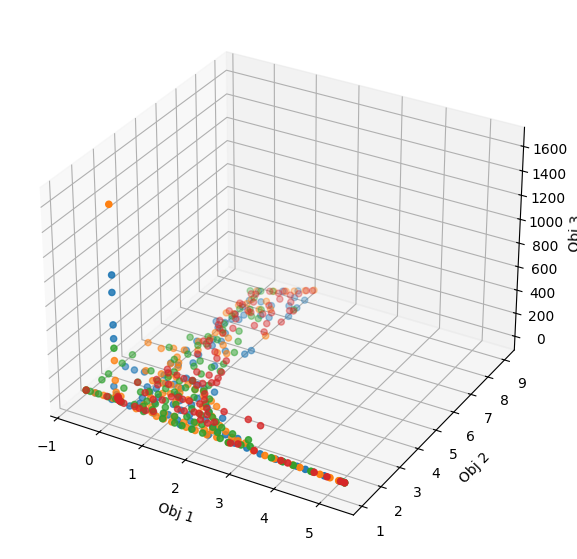

In [8]:
f_eval1 = res1['front_eval']
f_eval2 = res2['front_eval']
f_eval3 = res3['front_eval']
f_eval4 = res4['front_eval']
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(f_eval1[:, 0], f_eval1[:, 1], f_eval1[:, 2])
sc = ax.scatter(f_eval2[:, 0], f_eval2[:, 1], f_eval2[:, 2])
sc = ax.scatter(f_eval3[:, 0], f_eval3[:, 1], f_eval3[:, 2])
sc = ax.scatter(f_eval4[:, 0], f_eval4[:, 1], f_eval4[:, 2])
ax.set_xlabel('Obj 1')
ax.set_ylabel('Obj 2')
ax.set_zlabel('Obj 3')
plt.show()

### Convergence plots of the HV indicator

In [9]:
fmin, fmax = np.array([-0.721525, 1.13907204, 0.0]), np.array([5.30670000e+00, 9.06681054e+00, 4.32347058e+09])
ref_point = np.ones(3)*1.1
data1 = {'Iter': [], 'Neval': [], 'Time': [], 'HV': []}
for i in range(1,len(hist1)):
    data1['Iter'].append(hist1[i]['iteration'])
    data1['Neval'].append(np.min(hist1[i]['nfe_array']))
    data1['Time'].append(hist1[i]['wall_clock_time']/1.e9)
    front_eval = hist1[i]['front_eval']
    if hist1[i]['iteration'] == 0:
        data1['HV'].append(0.0)
    else:
        nfront_eval = normalize(front_eval, fmin, fmax)
        mask = np.any(nfront_eval>=1.1, axis=1)
        nfront_eval = nfront_eval[np.logical_not(mask)]
        if len(nfront_eval)<1:
            data1['HV'].append(0.0)
        else:
            hv = hypervolume(nfront_eval).compute(ref_point)
            data1['HV'].append(hv)

data2 = {'Iter': [], 'Neval': [], 'Time': [], 'HV': []}
for i in range(1,len(hist2)):
    data2['Iter'].append(hist2[i]['iteration'])
    data2['Neval'].append(np.min(hist2[i]['nfe_array']))
    data2['Time'].append(hist2[i]['wall_clock_time']/1.e9)
    front_eval = hist2[i]['front_eval']
    if hist2[i]['iteration'] == 0:
        data2['HV'].append(0.0)
    else:
        nfront_eval = normalize(front_eval, fmin, fmax)
        mask = np.any(nfront_eval>=1.1, axis=1)
        nfront_eval = nfront_eval[np.logical_not(mask)]
        if len(nfront_eval)<1:
            data2['HV'].append(0.0)
        else:
            hv = hypervolume(nfront_eval).compute(ref_point)
            data2['HV'].append(hv)

data3 = {'Iter': [], 'Neval': [], 'Time': [], 'HV': []}
for i in range(1,len(hist3)):
    data3['Iter'].append(hist3[i]['iteration'])
    data3['Neval'].append(np.min(hist3[i]['nfe_array']))
    data3['Time'].append(hist3[i]['wall_clock_time']/1.e9)
    front_eval = hist3[i]['front_eval']
    if hist3[i]['iteration'] == 0:
        data3['HV'].append(0.0)
    else:
        nfront_eval = normalize(front_eval, fmin, fmax)
        mask = np.any(nfront_eval>=1.1, axis=1)
        nfront_eval = nfront_eval[np.logical_not(mask)]
        if len(nfront_eval)<1:
            data3['HV'].append(0.0)
        else:
            hv = hypervolume(nfront_eval).compute(ref_point)
            data3['HV'].append(hv)

data4 = {'Iter': [], 'Neval': [], 'Time': [], 'HV': []}
for i in range(1,len(hist4)):
    data4['Iter'].append(hist4[i]['iteration'])
    data4['Neval'].append(np.min(hist4[i]['nfe_array']))
    data4['Time'].append(hist4[i]['wall_clock_time']/1.e9)
    front_eval = hist4[i]['front_eval']
    if hist4[i]['iteration'] == 0:
        data4['HV'].append(0.0)
    else:
        nfront_eval = normalize(front_eval, fmin, fmax)
        mask = np.any(nfront_eval>=1.1, axis=1)
        nfront_eval = nfront_eval[np.logical_not(mask)]
        if len(nfront_eval)<1:
            data4['HV'].append(0.0)
        else:
            hv = hypervolume(nfront_eval).compute(ref_point)
            data4['HV'].append(hv)

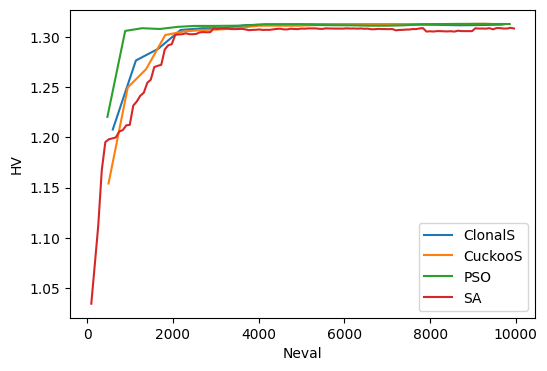

In [10]:
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
sc1 = ax.plot(data1['Neval'], data1['HV'], label='ClonalS')
sc2 = ax.plot(data2['Neval'], data2['HV'], label='CuckooS')
sc2 = ax.plot(data3['Neval'], data3['HV'], label='PSO')
sc2 = ax.plot(data4['Neval'], data4['HV'], label='SA')
ax.set_xlabel('Neval')
ax.set_ylabel('HV')
plt.legend()
plt.show()